Model: prajjwal1/bert-tiny


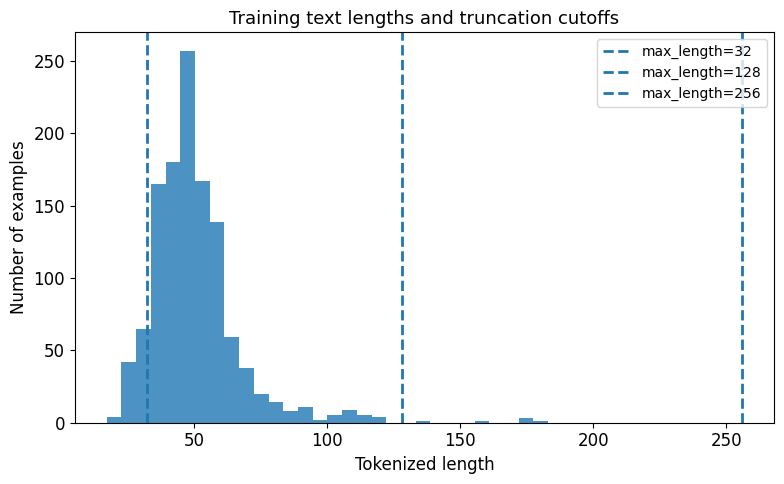

Alt-text: Histogram showing token lengths with cutoff lines at 32, 128, and 256 tokens.

Running max_length=32


Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

Step,Training Loss


...

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect i

Step,Training Loss


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   max_length   val_acc  test_acc    runtime  truncation_rate  retention
0          32  0.423333  0.415000  12.953135           0.9225   0.683082
1         128  0.313333  0.278333  14.077912           0.0050   0.998878
2         256  0.456667  0.505000  28.976552           0.0000   1.000000


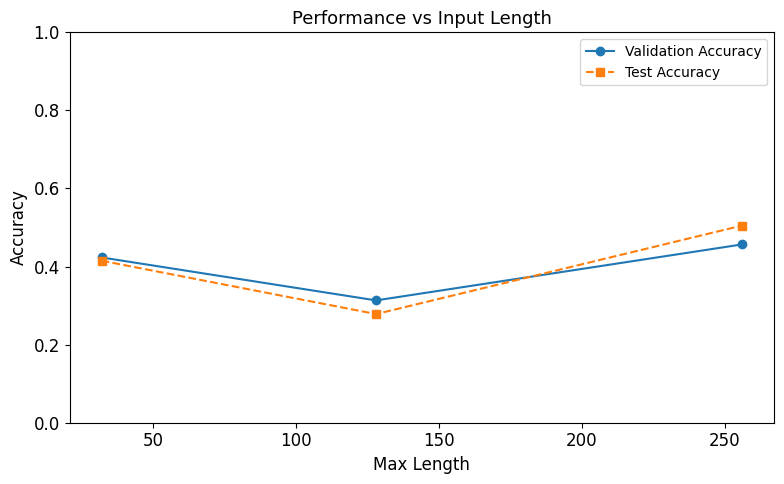

Alt-text: Accuracy increases with input length and begins to plateau.


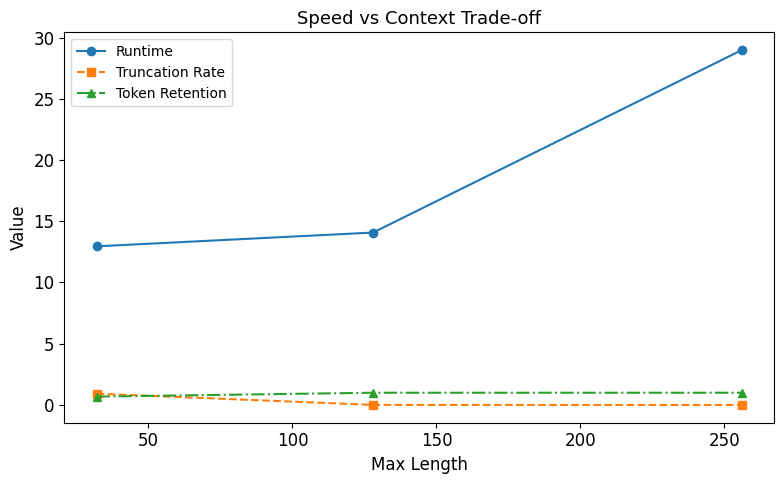

Alt-text: Longer inputs reduce truncation but increase runtime.


In [3]:
# =========================
# INSTALL (uncomment if needed)
# =========================
# !pip install -q transformers datasets scikit-learn matplotlib pandas numpy torch

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed,
)

# =========================
# REPRODUCIBILITY
# =========================
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# =========================
# ACCESSIBLE PLOTTING
# =========================
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["legend.fontsize"] = 10

# =========================
# CONFIG (FAST VERSION)
# =========================
MODEL_NAME = "prajjwal1/bert-tiny"
DATASET_NAME = "ag_news"
TEXT_COL = "text"
LABEL_COL = "label"

MAX_LENGTHS = [32, 128, 256]

TRAIN_SAMPLES = 1200
VALID_SAMPLES = 300
TEST_SAMPLES = 600

NUM_EPOCHS = 1
BATCH_SIZE = 16
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.01

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Model:", MODEL_NAME)

# =========================
# LOAD DATA
# =========================
raw = load_dataset(DATASET_NAME)

raw_train = raw["train"].shuffle(seed=SEED)
raw_test = raw["test"].shuffle(seed=SEED)

train_ds = raw_train.select(range(TRAIN_SAMPLES))
valid_ds = raw_train.select(range(TRAIN_SAMPLES, TRAIN_SAMPLES + VALID_SAMPLES))
test_ds = raw_test.select(range(TEST_SAMPLES))

dataset = DatasetDict({
    "train": train_ds,
    "validation": valid_ds,
    "test": test_ds,
})

label_names = dataset["train"].features[LABEL_COL].names
num_labels = len(label_names)

# =========================
# TOKEN LENGTH ANALYSIS
# =========================
def token_lengths(texts):
    return [len(tokenizer.encode(t, truncation=False)) for t in texts]

train_lengths = token_lengths(dataset["train"][TEXT_COL])

# =========================
# PLOT 1: LENGTH DISTRIBUTION
# =========================
fig, ax = plt.subplots()
ax.hist(train_lengths, bins=30, alpha=0.8)

for cutoff in MAX_LENGTHS:
    ax.axvline(cutoff, linestyle="--", linewidth=2, label=f"max_length={cutoff}")

ax.set_title("Training text lengths and truncation cutoffs")
ax.set_xlabel("Tokenized length")
ax.set_ylabel("Number of examples")
ax.legend()
plt.tight_layout()
plt.show()

print("Alt-text: Histogram showing token lengths with cutoff lines at 32, 128, and 256 tokens.")

# =========================
# HELPERS
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
    }

def truncation_stats(texts, max_length):
    lengths = [len(tokenizer.encode(t, truncation=False)) for t in texts]
    truncated = [l > max_length for l in lengths]
    retained = [min(l, max_length)/l for l in lengths]
    return np.mean(truncated), np.mean(retained)

def tokenize_function(batch, max_length):
    return tokenizer(batch[TEXT_COL], truncation=True, max_length=max_length)

# =========================
# EXPERIMENT LOOP
# =========================
results = []

for max_length in MAX_LENGTHS:
    print(f"\nRunning max_length={max_length}")

    tokenized = DatasetDict({
        split: dataset[split].map(
            lambda batch: tokenize_function(batch, max_length),
            batched=True,
            remove_columns=[TEXT_COL],
        )
        for split in dataset.keys()
    })

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels
    )

    args = TrainingArguments(
        output_dir=f"./tmp_{max_length}",
        do_eval=True,
        save_strategy="no",
        logging_strategy="no",
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    runtime = time.time() - start

    val_metrics = trainer.evaluate(tokenized["validation"])
    test_output = trainer.predict(tokenized["test"])

    preds = np.argmax(test_output.predictions, axis=-1)
    labels = test_output.label_ids

    trunc_rate, retention = truncation_stats(dataset["train"][TEXT_COL], max_length)

    results.append({
        "max_length": max_length,
        "val_acc": val_metrics["eval_accuracy"],
        "test_acc": accuracy_score(labels, preds),
        "runtime": runtime,
        "truncation_rate": trunc_rate,
        "retention": retention,
    })

results_df = pd.DataFrame(results)
print(results_df)

# =========================
# PLOT 2: PERFORMANCE
# =========================
fig, ax = plt.subplots()

ax.plot(results_df["max_length"], results_df["val_acc"], marker="o", label="Validation Accuracy")
ax.plot(results_df["max_length"], results_df["test_acc"], marker="s", linestyle="--", label="Test Accuracy")

ax.set_title("Performance vs Input Length")
ax.set_xlabel("Max Length")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print("Alt-text: Accuracy increases with input length and begins to plateau.")

# =========================
# PLOT 3: TRADE-OFF
# =========================
fig, ax = plt.subplots()

ax.plot(results_df["max_length"], results_df["runtime"], marker="o", label="Runtime")
ax.plot(results_df["max_length"], results_df["truncation_rate"], marker="s", linestyle="--", label="Truncation Rate")
ax.plot(results_df["max_length"], results_df["retention"], marker="^", linestyle="-.", label="Token Retention")

ax.set_title("Speed vs Context Trade-off")
ax.set_xlabel("Max Length")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

print("Alt-text: Longer inputs reduce truncation but increase runtime.")